# Cross-Price-Mode Evaluation

Deliberately crosses `eval_raw.py`'s price-mode firewall -- which is enforced only by
`FORECASTERS`' dict shape (a forecaster trained under one price structure is simply never
listed under the other's key), not a runtime check -- to see how a forecaster trained
under ONE price structure performs when its quantile output is instead run through the
OTHER structure's dispatch/settlement pipeline, via `evaluate_one_pair` directly.

Both directions, balanced ("standard battery") archetype throughout -- the only
archetype both markets' default unsuffixed checkpoints share:
- **A**: `dfl_1stage_dual-price` (dual-price-trained) -> SINGLE-price pipeline
- **B**: `dfl_1stage_single-price` (single-price-trained) -> DUAL-price pipeline

Both against the SAME full sealed test year (366 days) the main grid
(`eval_raw.run_full_evaluation_grid`) already used, so native-vs-cross comparisons are
apples-to-apples. Outputs saved to `8_testing/results/cross_eval/` -- kept OUT of
`raw_daily/` so they can never be silently picked up by `aggregate_results.ipynb`'s
normal price_mode-filtered queries. Cached on disk (re-loaded if present) since each
direction is a real ~2-3 min, 366-day dispatch solve -- delete the parquet to force a
re-run.

In [1]:
from __future__ import annotations
import sys
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
from eval_raw import (
    load_test_windows, evaluate_one_pair, precompute_test_oracle_costs,
    fresh_baseline_model, dfl_model_from, FixedParams, RAW_DAILY_DIR,
    FORECASTING_DIR, DFL_TRAIN_DIR, COPULA_DIR, FrozenCopulaSampler,
    N_SCEN, GAMMA,
)

CROSS_EVAL_DIR = here() / "8_testing" / "results" / "cross_eval"
CROSS_EVAL_DIR.mkdir(parents=True, exist_ok=True)
ARCHETYPE = ("balanced", 2.0, 2.0, 4.0)

pd.set_option("display.width", 160)

## Load test windows + both DFL forecasters

In [2]:
print("loading test windows...")
windows = load_test_windows()

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
baseline_model = fresh_baseline_model(baseline_ckpt)
sc = baseline_ckpt["scaler_stats"]


def load_dfl(forecaster_id: str):
    ck = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    return dfl_model_from(baseline_ckpt, ck)


dfl_single = load_dfl("dfl_1stage_single-price")
dfl_dual = load_dfl("dfl_1stage_dual-price")

cop = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
sampler = FrozenCopulaSampler(cop["Z_corr"], cop["quantile_levels"])
quantile_levels = cop["quantile_levels"]

arch_name, C_ch, C_dis, B_max = ARCHETYPE
fp = FixedParams(T_total=24, num_scenarios=N_SCEN, dt=1.0, eta_ch=0.95, eta_dis=0.95,
                  C_ch=C_ch, C_dis=C_dis, B_max=B_max, SOC0=0.5 * B_max, gamma=GAMMA)
print(f"n_test_days={len(windows.delivery_start)}")

loading test windows...
[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)


n_test_days=366


## Direction A -- dual-price-trained forecaster on the SINGLE-price pipeline

In [3]:
oracle_single = precompute_test_oracle_costs(windows, "single-price", fp)

cross_a_path = CROSS_EVAL_DIR / "dfl_dual-price_ON_single-price_eval__balanced.parquet"
if cross_a_path.exists():
    cross_a = pd.read_parquet(cross_a_path)
    print(f"loaded cached: {cross_a_path} ({len(cross_a)} days)")
else:
    print("evaluating dual-price-trained forecaster on the SINGLE-PRICE pipeline...", flush=True)
    cross_a = evaluate_one_pair(
        dfl_dual, sc, sampler, windows, baseline_model, quantile_levels,
        forecaster_id="dfl_1stage_dual-price_ON_single-price", price_mode="single-price",
        archetype_name=arch_name, C_ch=C_ch, C_dis=C_dis, B_max=B_max,
        oracle_costs=oracle_single, out_path=cross_a_path, n_days=None,
    )
    print(f"done: {len(cross_a)} days -> {cross_a_path}")

Set parameter WLSAccessID


Set parameter WLSSecret


Set parameter LicenseID to value 2828580


Academic license 2828580 - for non-commercial use only - registered to al___@ucl.ac.uk


/home/fleet75/diss_bess/6_models/oracle.py:126: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  bundle.problem.solve(solver=solver, **solver_kwargs)


loaded cached: /home/fleet75/diss_bess/8_testing/results/cross_eval/dfl_dual-price_ON_single-price_eval__balanced.parquet (366 days)


## Direction B -- single-price-trained forecaster on the DUAL-price pipeline

In [4]:
oracle_dual = precompute_test_oracle_costs(windows, "dual-price", fp)

cross_b_path = CROSS_EVAL_DIR / "dfl_single-price_ON_dual-price_eval__balanced.parquet"
if cross_b_path.exists():
    cross_b = pd.read_parquet(cross_b_path)
    print(f"loaded cached: {cross_b_path} ({len(cross_b)} days)")
else:
    print("evaluating single-price-trained forecaster on the DUAL-PRICE pipeline...", flush=True)
    cross_b = evaluate_one_pair(
        dfl_single, sc, sampler, windows, baseline_model, quantile_levels,
        forecaster_id="dfl_1stage_single-price_ON_dual-price", price_mode="dual-price",
        archetype_name=arch_name, C_ch=C_ch, C_dis=C_dis, B_max=B_max,
        oracle_costs=oracle_dual, out_path=cross_b_path, n_days=None,
    )
    print(f"done: {len(cross_b)} days -> {cross_b_path}")

/home/fleet75/diss_bess/6_models/oracle.py:126: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  bundle.problem.solve(solver=solver, **solver_kwargs)


loaded cached: /home/fleet75/diss_bess/8_testing/results/cross_eval/dfl_single-price_ON_dual-price_eval__balanced.parquet (366 days)


## Comparison tables

For each direction: an aggregate table (baseline / native DFL / cross-evaluated DFL, all
under the SAME pipeline) plus a direct paired head-to-head between the native and
cross-evaluated forecasters specifically -- mean/median of (cross - native) and win rates
both ways, since the aggregate table alone can hide a right-skewed win/loss pattern (as it
did for Direction A when this was first checked in chat).

In [5]:
def build_comparison(native_df, cross_df, baseline_df, native_label, cross_label):
    base = baseline_df.set_index("day")
    native = native_df.set_index("day")
    cross = cross_df.set_index("day")

    rows = []
    for label, frame in [("baseline", base), (native_label, native), (cross_label, cross)]:
        paired = base[["total_cost"]].join(frame[["total_cost"]], lsuffix="_base", rsuffix="_x", how="inner")
        delta = paired["total_cost_x"] - paired["total_cost_base"]
        # daily_abs_imbalance: sum_h |p_imb_h| per day (MWh, dt=1h) -- one value per day
        daily_abs_imbalance = frame["p_imb"].apply(lambda x: np.abs(np.asarray(x)).sum())
        rows.append({
            "forecaster": label,
            "mean_daily_cost": frame["total_cost"].mean(),
            "mean_regret_v_oracle": frame["regret_v_oracle"].mean(),
            "median_delta_vs_baseline": np.nan if label == "baseline" else delta.median(),
            "pct_change_vs_baseline": np.nan if label == "baseline" else 100 * delta.mean() / paired["total_cost_base"].mean(),
            "win_rate_vs_baseline": np.nan if label == "baseline" else float((delta < 0).mean()),
            "mean_crps": frame["crps"].mean(),
            "mean_abs_daily_imbalance_MWh": daily_abs_imbalance.mean(),
            "total_abs_imbalance_MWh": daily_abs_imbalance.sum(),
        })
    agg_table = pd.DataFrame(rows)

    paired_h2h = native[["total_cost"]].join(cross[["total_cost"]], lsuffix="_native", rsuffix="_cross", how="inner")
    delta_h2h = paired_h2h["total_cost_cross"] - paired_h2h["total_cost_native"]
    h2h = {
        "n_days": len(paired_h2h),
        "mean(cross - native)": delta_h2h.mean(),
        "median(cross - native)": delta_h2h.median(),
        "cross_win_rate": float((delta_h2h < 0).mean()),
        "native_win_rate": float((delta_h2h > 0).mean()),
    }
    return agg_table, h2h

In [6]:
native_single = pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", "single-price"), ("archetype_name", "=", "balanced"), ("forecaster_id", "=", "dfl_1stage_single-price")])
baseline_single = pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", "single-price"), ("archetype_name", "=", "balanced"), ("forecaster_id", "=", "baseline")])

agg_a, h2h_a = build_comparison(native_single, cross_a, baseline_single,
                                 "DFL single-price (native)", "DFL dual-price (cross-eval)")
print("=== Direction A: dual-price-trained forecaster on the SINGLE-price pipeline ===")
display(agg_a)
print(h2h_a)

=== Direction A: dual-price-trained forecaster on the SINGLE-price pipeline ===


,forecaster,mean_daily_cost,mean_regret_v_oracle,median_delta_vs_baseline,pct_change_vs_baseline,win_rate_vs_baseline,mean_crps,mean_abs_daily_imbalance_MWh,total_abs_imbalance_MWh
0,baseline,1746.546188,14.955222,NaN,NaN,NaN,0.267694,8.753236,3203.684556
1,DFL single-price (native),1741.846968,10.256002,-2.577588,-0.269058,0.576503,0.290603,9.137084,3344.172593
2,DFL dual-price (cross-eval),1744.386345,12.795379,-0.433117,-0.123664,0.513661,0.266678,8.507170,3113.624076


{'n_days': 366, 'mean(cross - native)': np.float64(2.5393771309621425), 'median(cross - native)': np.float64(2.135702398270155), 'cross_win_rate': 0.42896174863387976, 'native_win_rate': 0.5710382513661202}


In [7]:
native_dual = pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", "dual-price"), ("archetype_name", "=", "balanced"), ("forecaster_id", "=", "dfl_1stage_dual-price")])
baseline_dual = pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", "dual-price"), ("archetype_name", "=", "balanced"), ("forecaster_id", "=", "baseline")])

agg_b, h2h_b = build_comparison(native_dual, cross_b, baseline_dual,
                                 "DFL dual-price (native)", "DFL single-price (cross-eval)")
print("=== Direction B: single-price-trained forecaster on the DUAL-price pipeline ===")
display(agg_b)
print(h2h_b)

=== Direction B: single-price-trained forecaster on the DUAL-price pipeline ===


,forecaster,mean_daily_cost,mean_regret_v_oracle,median_delta_vs_baseline,pct_change_vs_baseline,win_rate_vs_baseline,mean_crps,mean_abs_daily_imbalance_MWh,total_abs_imbalance_MWh
0,baseline,1797.543722,65.780299,NaN,NaN,NaN,0.267694,8.478865,3103.264516
1,DFL dual-price (native),1795.491146,63.727722,-0.526856,-0.114188,0.527322,0.266678,8.235983,3014.369657
2,DFL single-price (cross-eval),1797.986602,66.223178,3.331881,0.024638,0.418033,0.290603,8.897691,3256.555028


{'n_days': 366, 'mean(cross - native)': np.float64(2.4954563125677676), 'median(cross - native)': np.float64(2.6761241408757996), 'cross_win_rate': 0.3879781420765027, 'native_win_rate': 0.6120218579234973}


## Seed-averaged transfer check (RQ2)

Both directions above are single-seed (20240801). Since the within-mode economic effect
(`9_analysis/why_dfl_helps.md` Part 3) turned out to be seed-unstable, a transfer claim
built on one seed's checkpoint is equally suspect until checked. `cross_eval_seeded.py`
(run once, standalone, mirroring this notebook's own `evaluate_one_pair` calls exactly)
cross-evaluated all N=5 seeds -- `20240801` (already cached above) plus
`20240802`-`20240805` -- in both directions, saved to the same `cross_eval/` directory
with the project's `_seed{N}` suffix convention. This cell aggregates all 5 per
direction: mean/std/range/win-rate of `pct_change_vs_baseline`, plus a one-sample
t-test against zero (same diagnostic used for the native seed campaign) and the native
(within-mode) N=5 numbers alongside for direct comparison.

In [8]:
from scipy import stats

SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]


def seed_suffix(seed):
    return "" if seed == 20240801 else f"_seed{seed}"


def pct_and_win(df, base_df):
    base = base_df.set_index("day")["total_cost"]
    x = df.set_index("day")["total_cost"]
    delta = x - base
    return 100 * delta.mean() / base.mean(), 100 * float((delta < 0).mean())


def seed_averaged_row(label, pcts, wins):
    pcts = np.asarray(pcts)
    t, p = stats.ttest_1samp(pcts, 0.0)
    return {
        "forecaster": label,
        "pct_change_mean": pcts.mean(),
        "pct_change_std": pcts.std(ddof=1),
        "pct_change_min": pcts.min(),
        "pct_change_max": pcts.max(),
        "win_rate_mean": np.mean(wins),
        "t_vs_zero": t,
        "p_vs_zero": p,
    }


def native_seed_pcts(mode):
    base = pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", mode), ("archetype_name", "=", "balanced"), ("forecaster_id", "=", "baseline")])
    pcts, wins = [], []
    for seed in SEEDS:
        fid = f"dfl_1stage_{mode}{seed_suffix(seed)}"
        df = pd.read_parquet(RAW_DAILY_DIR, filters=[("price_mode", "=", mode), ("archetype_name", "=", "balanced"), ("forecaster_id", "=", fid)])
        pct, win = pct_and_win(df, base)
        pcts.append(pct); wins.append(win)
    return pcts, wins


# Direction A: dual-price-trained -> SINGLE-price pipeline
pcts_a, wins_a = [], []
for seed in SEEDS:
    df = pd.read_parquet(CROSS_EVAL_DIR / f"dfl_dual-price_ON_single-price_eval__balanced{seed_suffix(seed)}.parquet")
    pct, win = pct_and_win(df, baseline_single)
    pcts_a.append(pct); wins_a.append(win)
pcts_native_single, wins_native_single = native_seed_pcts("single-price")

rows_a = [
    seed_averaged_row("DFL single-price (native)", pcts_native_single, wins_native_single),
    seed_averaged_row("DFL dual-price (cross-eval)", pcts_a, wins_a),
]
print("=== Direction A, seed-averaged (N=5): evaluated on the SINGLE-price pipeline ===")
display(pd.DataFrame(rows_a))

# Direction B: single-price-trained -> DUAL-price pipeline
pcts_b, wins_b = [], []
for seed in SEEDS:
    df = pd.read_parquet(CROSS_EVAL_DIR / f"dfl_single-price_ON_dual-price_eval__balanced{seed_suffix(seed)}.parquet")
    pct, win = pct_and_win(df, baseline_dual)
    pcts_b.append(pct); wins_b.append(win)
pcts_native_dual, wins_native_dual = native_seed_pcts("dual-price")

rows_b = [
    seed_averaged_row("DFL dual-price (native)", pcts_native_dual, wins_native_dual),
    seed_averaged_row("DFL single-price (cross-eval)", pcts_b, wins_b),
]
print("\n=== Direction B, seed-averaged (N=5): evaluated on the DUAL-price pipeline ===")
display(pd.DataFrame(rows_b))

print("\nDirection A per-seed pct_change:", [f"{p:+.4f}%" for p in pcts_a])
print("Direction B per-seed pct_change:", [f"{p:+.4f}%" for p in pcts_b])

=== Direction A, seed-averaged (N=5): evaluated on the SINGLE-price pipeline ===


,forecaster,pct_change_mean,pct_change_std,pct_change_min,pct_change_max,win_rate_mean,t_vs_zero,p_vs_zero
0,DFL single-price (native),-0.010830,0.147048,-0.269058,0.097711,51.092896,-0.164689,0.877177
1,DFL dual-price (cross-eval),-0.022062,0.068620,-0.123664,0.059575,50.054645,-0.718900,0.511960



=== Direction B, seed-averaged (N=5): evaluated on the DUAL-price pipeline ===


,forecaster,pct_change_mean,pct_change_std,pct_change_min,pct_change_max,win_rate_mean,t_vs_zero,p_vs_zero
0,DFL dual-price (native),0.060294,0.149451,-0.114188,0.222765,42.568306,0.902113,0.418007
1,DFL single-price (cross-eval),0.263642,0.139587,0.024638,0.391029,34.043716,4.223332,0.013442



Direction A per-seed pct_change: ['-0.1237%', '-0.0366%', '+0.0180%', '-0.0276%', '+0.0596%']
Direction B per-seed pct_change: ['+0.0246%', '+0.3178%', '+0.2935%', '+0.3910%', '+0.2912%']


## Visual summary

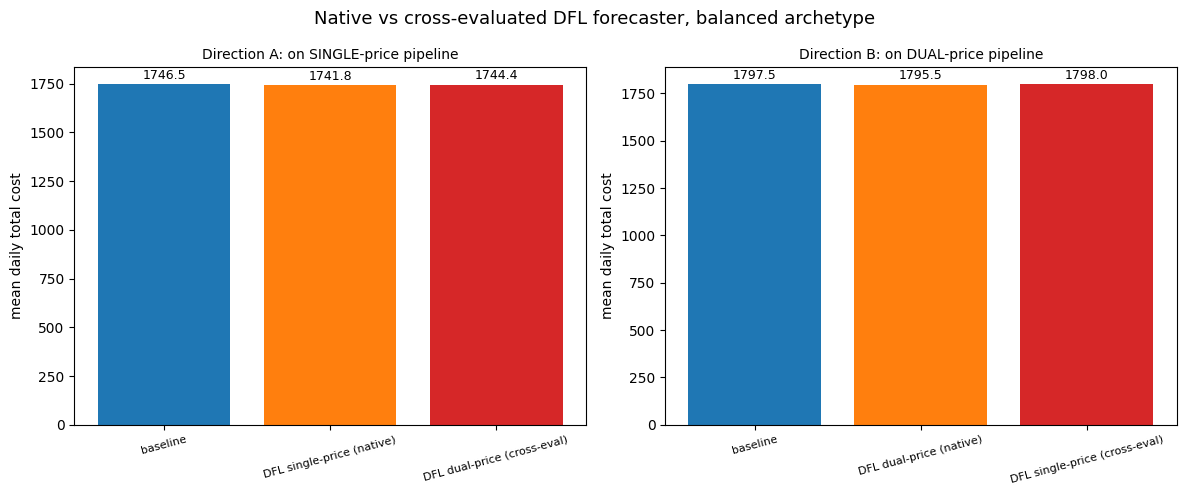

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (agg, title) in zip(axes, [(agg_a, "Direction A: on SINGLE-price pipeline"),
                                     (agg_b, "Direction B: on DUAL-price pipeline")]):
    colors = ["C0", "C1", "C3"]
    bars = ax.bar(agg["forecaster"], agg["mean_daily_cost"], color=colors)
    for bar, val in zip(bars, agg["mean_daily_cost"]):
        ax.annotate(f"{val:.1f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
    ax.set_ylabel("mean daily total cost")
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", labelrotation=15, labelsize=8)

fig.suptitle("Native vs cross-evaluated DFL forecaster, balanced archetype", fontsize=13)
fig.tight_layout()
plt.show()

## Net imbalance comparison (Direction A)

Does the dual-price-trained forecaster's mean end up better-CENTRED than the native
single-price forecaster's, when both are settled through the SAME single-price pipeline?
`p_imb = realised - mean` exactly here (single-price always has `D_ch=D_dis=0`, no
recourse -- established earlier), so this is computable directly from the `mean`/
`realised` columns already stored, no re-solving needed.

Two metrics, since they tell different stories:
- **net imbalance** = `sum(realised - mean)` per day -- a SIGNED daily total. Near zero
  means the forecaster isn't systematically over- or under-predicting; large magnitude
  (either sign) means a persistent bias.
- **imbalance volume** (`imbalance_volume_abs_MWh`, already in the schema) = `sum(|p_imb|)`
  per day -- the GROSS hour-to-hour churn regardless of sign. A forecaster can have small
  net imbalance while still swinging wildly hour to hour (large positive and negative
  errors cancelling in the sum) -- volume catches that, net alone can't.

Ties to the mechanism from chat: single-price's `C_imb` is LINEAR in the forecast mean (no
minimum, a constant directional nudge set by price sign only), while dual-price's `C_imb`
is V-shaped -- an asymmetric-pinball-loss-shaped function of the mean, minimised exactly
at `realised`. If that's right, the dual-price-trained forecaster's mean should show BOTH
lower net imbalance AND lower volume here, not a trade-off between them.

In [10]:
def net_imbalance_stats(df, label):
    net = df.apply(lambda r: float(np.sum(np.asarray(r["realised"]) - np.asarray(r["mean"]))), axis=1)
    abs_vol = df["imbalance_volume_abs_MWh"]
    return {
        "forecaster": label,
        "mean_net_imbalance_MWh": net.mean(),
        "std_net_imbalance_MWh": net.std(),
        "mean_abs_net_imbalance_MWh": net.abs().mean(),
        "mean_abs_imbalance_volume_MWh": abs_vol.mean(),
        "net/abs_ratio": net.abs().mean() / abs_vol.mean(),
    }, net


native_single_dfl = native_single  # already loaded above (Comparison tables section)
imb_rows, imb_series = [], {}
for label, df in [
    ("baseline", baseline_single),
    ("DFL single-price (native)", native_single_dfl),
    ("DFL dual-price (cross-eval)", cross_a),
]:
    stats, net = net_imbalance_stats(df, label)
    imb_rows.append(stats)
    imb_series[label] = net

imbalance_table = pd.DataFrame(imb_rows)
display(imbalance_table)

,forecaster,mean_net_imbalance_MWh,std_net_imbalance_MWh,mean_abs_net_imbalance_MWh,mean_abs_imbalance_volume_MWh,net/abs_ratio
0,baseline,-3.230339,6.849475,5.807024,8.753236,0.663415
1,DFL single-price (native),-2.365433,6.314078,5.234638,9.137084,0.572900
2,DFL dual-price (cross-eval),-2.077625,6.527772,5.351602,8.507170,0.629070


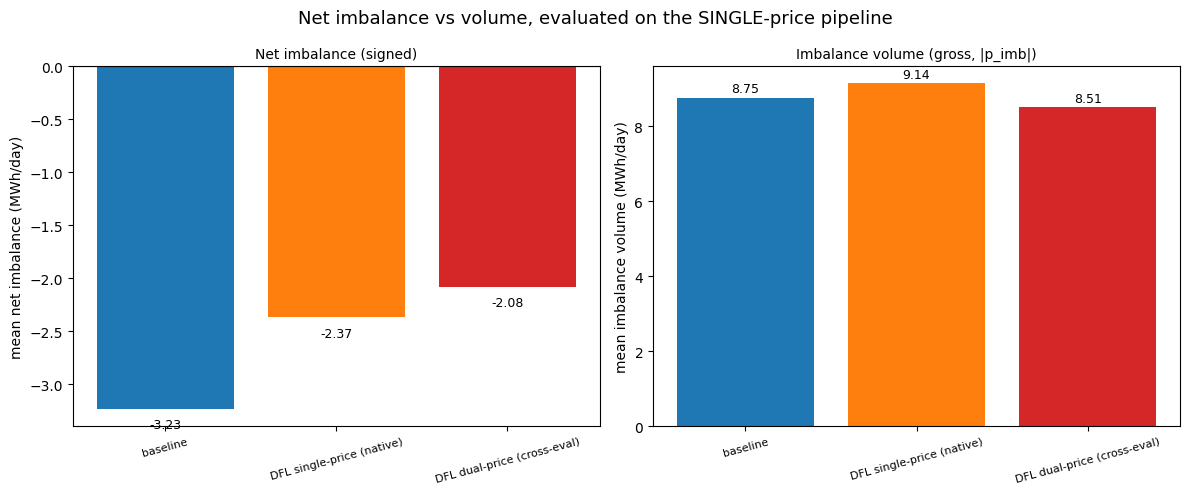

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ["C0", "C1", "C3"]

bars1 = ax1.bar(imbalance_table["forecaster"], imbalance_table["mean_net_imbalance_MWh"], color=colors)
ax1.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars1, imbalance_table["mean_net_imbalance_MWh"]):
    ax1.annotate(f"{val:+.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 textcoords="offset points", xytext=(0, 4 if val >= 0 else -14), ha="center", fontsize=9)
ax1.set_ylabel("mean net imbalance (MWh/day)")
ax1.set_title("Net imbalance (signed)", fontsize=10)
ax1.tick_params(axis="x", labelrotation=15, labelsize=8)

bars2 = ax2.bar(imbalance_table["forecaster"], imbalance_table["mean_abs_imbalance_volume_MWh"], color=colors)
for bar, val in zip(bars2, imbalance_table["mean_abs_imbalance_volume_MWh"]):
    ax2.annotate(f"{val:.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
ax2.set_ylabel("mean imbalance volume (MWh/day)")
ax2.set_title("Imbalance volume (gross, |p_imb|)", fontsize=10)
ax2.tick_params(axis="x", labelrotation=15, labelsize=8)

fig.suptitle("Net imbalance vs volume, evaluated on the SINGLE-price pipeline", fontsize=13)
fig.tight_layout()
plt.show()